In [1]:
# ДЗ
# 1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.

In [35]:
import math
import numpy as np
import cv2
from scipy import ndimage
import matplotlib.pyplot as plt

In [12]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = cv2.imread('palm_1.jpg')
image_pl = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray_pl = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [13]:
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])                                                        
    if abs(av_val - img[point]) <= T:
        return True
    return False

def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i,j] == 0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        print(count)
        mask += local_mask
    return mask * 255

<h1>1. Подбор параметров алгоритма разрастания регионов для выделения всего участка газона.</h1>

35
85
135
185
235
282
334
385
435
485
535
585
635
685
734
623
566
587
607
620
607
604
594
580
571
558
539
528
516
501
481
467
452
435
429
432
420
413
412
412
408
421
399
405
418
417
418
415
384
344
359
390
409
488
458
452
458
455
444
445
403
383
368
366
374
366
377
366
357
381
374
369
415
475
484
417
420
388
386
401
388
383
490
402
383
388
413
401
445
488
514
547
575
529
466
694
541
525
526
509
539
544
562
580
598
604
579
577
575
565
557
569
555
554
520
515
513
571
618
636
673
743
765
653
546
427
417
403
405
400
433
475
528
596
607
600
592
575
553
552
568
577
613
636
661
625
526
554
592
565
549
559
519
973
503
510
487
487
489
489
490
489
500
505
502
496
489
483
487
315
142
153
139
138
135
125
106
90
68
59
49
48
47
44
42
39
36
31
29
29
13
0


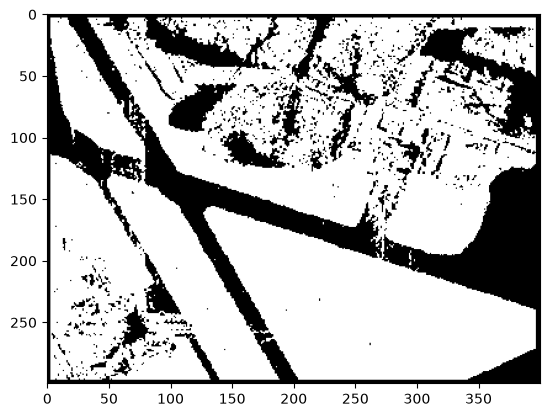

In [48]:
seed_point = (250, 250)
mask1 = region_growing(image_gray, seed_point, homo_average, 3, 32)
plt.imshow(mask1, cmap="gray")

<h1>2. Реализуйте вычисление критерия однородности, отличного от представленного</h1>

In [16]:
def homo_min_max(img, mask, point, T):
    region_pixels = img[mask > 0]
    new_pixel_val = img[point]
    if region_pixels.size == 0:
        return True
    current_min = region_pixels.min()
    current_max = region_pixels.max()

    new_min = min(current_min, new_pixel_val)
    new_max = max(current_max, new_pixel_val)
    if (new_max - new_min) <= T:
        return True
    return False

63
161
259
357
453
553
651
749
847
945
1043
886
850
877
867
849
823
799
767
731
713
721
788
802
769
762
786
832
859
913
942
995
950
925
923
950
874
897
943
992
1010
1071
1143
1165
1179
923
1019
1002
1006
1078
1075
1065
927
925
914
961
999
1098
1075
1068
1084
1106
1105
1108
1175
1189
1154
1135
1180
1225
1187
1086
1086
1067
1060
1090
1125
1190
1301
1318
1378
1432
453
421
453
486
499
452
471
494
513
536
516
464
475
425
366
358
354
274
169
152
155
123
109
90
75
68
64
57
52
43
38
0


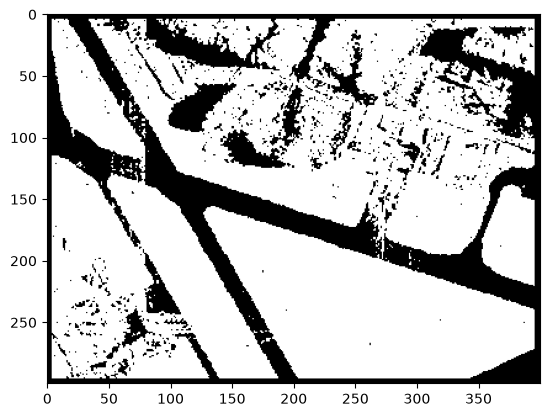

In [24]:
mask_min_max = region_growing(image_gray, seed_point, homo_min_max, 4, 70)
plt.imshow(mask_min_max, cmap="gray")
plt.show()

<h4>Реализован алгоритм вычисления критерия однородности на основе динамического диапазона яркости</h4>
Данный алгоритм справился с задачей быстрее.

<h1>3. Алгоритм сегментации watershed+distance transform для задачи подсчета пальмовых деревьев.</h1>

Text(0.5, 1.0, 'Исходное изображение')

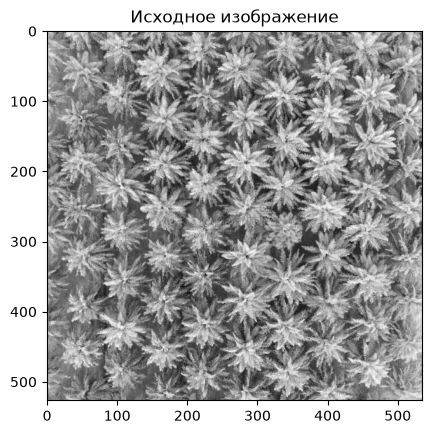

In [26]:
plt.imshow(image_gray_pl, cmap='gray')
plt.title('Исходное изображение')

Text(0.5, 1.0, 'После размытия Гаусса')

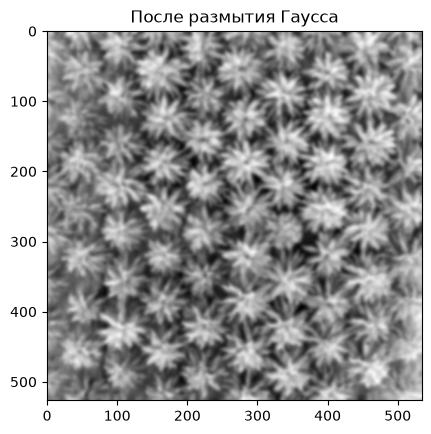

In [28]:
blurred = cv2.GaussianBlur(image_gray_pl, (13, 13), 0)
plt.imshow(blurred, cmap='gray')
plt.title('После размытия Гаусса')

Text(0.5, 1.0, 'Бинаризация')

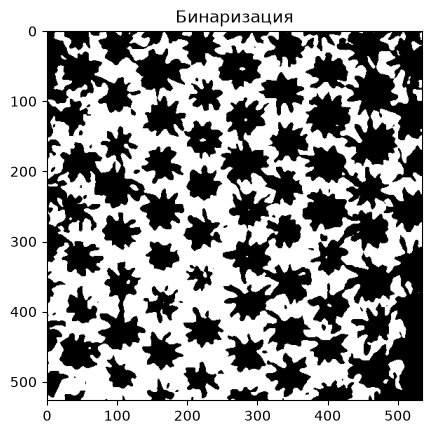

In [29]:
ret, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh, cmap='gray')
plt.title('Бинаризация')

Text(0.5, 1.0, 'Distance Transform')

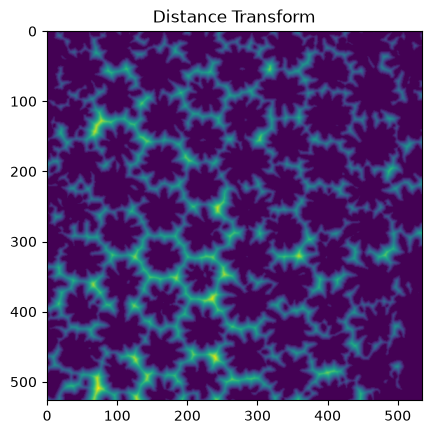

In [47]:
dist_transform = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
local_maxima = ndimage.maximum_filter(dist_transform, size=20, mode='constant')
plt.imshow(dist_transform)
plt.title('Distance Transform')

Text(0.5, 1.0, 'Найдено деревьев: 142')

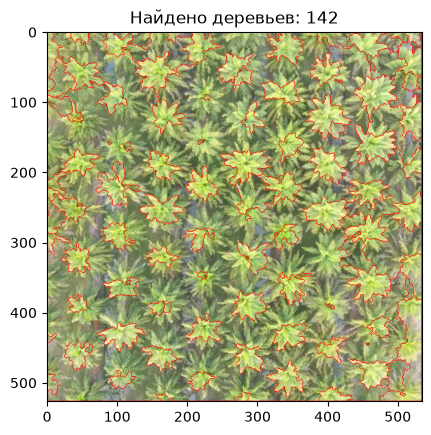

In [42]:
ret, sure_fg = cv2.threshold(dist_transform, 0.1 * dist_transform.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)
ret, markers = cv2.connectedComponents(sure_fg)
markers[dist_transform == local_maxima] = 1
markers = ndimage.label(markers)[0]  
markers = cv2.watershed(image_pl, markers.astype(np.int32))

num_trees = len(np.unique(markers)) - 1
segmented_image = image_pl.copy()
segmented_image[markers == -1] = [255, 0, 0]  
plt.imshow(segmented_image)
plt.title(f'Найдено деревьев: {num_trees}')